# HELPER FUNCTIONS *keeping the code clean

In [106]:
def create_target_horizons(price_5s, horizons=[5, 10, 15, 30, 45, 60], interval_seconds=5):
    """
    Create multi-horizon price change targets from a 5-second interval price dataframe.

    Parameters:
        price_5s (pd.DataFrame): DataFrame with 'price' column indexed by ts_event.
        horizons (list): List of prediction horizons in seconds.
        interval_seconds (int): Time interval of the price_5s DataFrame (default 5s).

    Returns:
        pd.DataFrame: target_horizons with columns for each horizon containing future price changes.
    """
    target_dict = {}
    
    # Compute shift in rows for each horizon
    rows_ahead = [h // interval_seconds for h in horizons]
    
    for h, n_rows in zip(horizons, rows_ahead):
        # Future price change = price at t+h minus current price
        target_dict[f"{h}s"] = price_5s['price'].shift(-n_rows) - price_5s['price']
    
    # Create DataFrame
    target_horizons = pd.DataFrame(target_dict, index=price_5s.index)
    
    # Drop rows with NaNs (last rows where future price doesn't exist)
    target_horizons = target_horizons.dropna()
    
    return target_horizons

### PROJECT BEGINS FROM THIS POINT ON

In [107]:
import pandas as pd

horizons = [5, 10, 15, 30, 45, 60]  # in seconds up to a minute

Below is preparing the target price data for the different horizons that is going to be run.

In [108]:

# import price data
df = pd.read_csv('first_25000_rows.csv')
price_df = df[['ts_event', 'price']]
price_df["ts_event"] = pd.to_datetime(price_df["ts_event"])
price_df.set_index("ts_event", inplace=True)

price_5s = price_df.resample('5s').first().reset_index()
price_5s = price_5s.dropna()
price_5s.set_index("ts_event", inplace=True)
print(price_5s)

                            price
ts_event                         
2024-10-21 11:54:25+00:00  233.62
2024-10-21 11:54:35+00:00  233.90
2024-10-21 11:54:40+00:00  233.67
2024-10-21 11:54:50+00:00  233.79
2024-10-21 11:54:55+00:00  233.48
...                           ...
2024-10-21 13:04:00+00:00  233.70
2024-10-21 13:04:05+00:00  233.68
2024-10-21 13:04:10+00:00  233.68
2024-10-21 13:04:15+00:00  233.54
2024-10-21 13:04:20+00:00  233.46

[643 rows x 1 columns]


/var/folders/z0/3xgjmk1d1n9b6gw4txcx8q5c0000gn/T/ipykernel_77474/2055662240.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df["ts_event"] = pd.to_datetime(price_df["ts_event"])


In [109]:
target_horizons = create_target_horizons(price_5s, horizons)
print(target_horizons)

                             5s   10s   15s   30s   45s   60s
ts_event                                                     
2024-10-21 11:54:25+00:00  0.28  0.05  0.17 -0.03 -0.02  0.11
2024-10-21 11:54:35+00:00 -0.23 -0.11 -0.42 -0.39 -0.23 -0.42
2024-10-21 11:54:40+00:00  0.12 -0.19 -0.08  0.06 -0.12  0.33
2024-10-21 11:54:50+00:00 -0.31 -0.20 -0.20 -0.19 -0.06 -0.04
2024-10-21 11:54:55+00:00  0.11  0.11  0.03  0.19  0.00  0.29
...                         ...   ...   ...   ...   ...   ...
2024-10-21 13:02:50+00:00 -0.06 -0.22 -0.01  0.04 -0.19  0.07
2024-10-21 13:02:55+00:00 -0.16  0.05  0.04  0.02 -0.12  0.11
2024-10-21 13:03:00+00:00  0.21  0.20  0.14  0.24  0.13  0.27
2024-10-21 13:03:05+00:00 -0.01 -0.07  0.05 -0.18  0.08 -0.08
2024-10-21 13:03:10+00:00 -0.06  0.06 -0.02 -0.16  0.07 -0.15

[631 rows x 6 columns]


# Importing all features and targets dataframes

In [110]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# pre-processed target horizons
target_horizons

# OFI features
ofi_best_level = pd.read_csv("feature_outputs/ofi_best_level.csv", index_col="ts_event", parse_dates=True)
multi_level_ofi = pd.read_csv("feature_outputs/ofi_multi_level.csv", index_col="ts_event", parse_dates=True)
integrated_ofi = pd.read_csv("feature_outputs/ofi_integrated.csv", index_col="ts_event", parse_dates=True)

ofi_best_level.index = pd.to_datetime(ofi_best_level.index).tz_localize('UTC')
multi_level_ofi.index = pd.to_datetime(multi_level_ofi.index).tz_localize('UTC')
integrated_ofi.index = pd.to_datetime(integrated_ofi.index).tz_localize('UTC')

ofi_all = pd.concat([ofi_best_level, multi_level_ofi, integrated_ofi], axis=1)
print("\nMerged OFI Features:")
print(ofi_all.head())

print("OFI Best Level:")
print(ofi_best_level.head())

print("\nMulti-Level OFI:")
print(multi_level_ofi.head())

print("\nIntegrated OFI:")
print(integrated_ofi.head())

print("\nTarget Horizons:")
print(target_horizons.head())


Merged OFI Features:
                           best_level_ofi  ofi_00  ofi_01  ofi_02  ofi_03  \
ts_event                                                                    
2024-10-21 11:54:25+00:00             3.0   100.0   100.0   100.0     0.0   
2024-10-21 11:54:30+00:00             0.0     0.0     0.0     0.0     0.0   
2024-10-21 11:54:35+00:00           401.0   -80.0   -80.0   -80.0   -80.0   
2024-10-21 11:54:40+00:00          -278.0   120.0   120.0   120.0   120.0   
2024-10-21 11:54:45+00:00             0.0     0.0     0.0     0.0     0.0   

                           ofi_04  ofi_05  ofi_06  ofi_07  ofi_08  ofi_09  \
ts_event                                                                    
2024-10-21 11:54:25+00:00     0.0     0.0     0.0     0.0     0.0     0.0   
2024-10-21 11:54:30+00:00     0.0     0.0     0.0     0.0     0.0     0.0   
2024-10-21 11:54:35+00:00   -80.0   -80.0   -80.0   -80.0   -80.0   -80.0   
2024-10-21 11:54:40+00:00   120.0   120.0   120.0   1

Testing for Stationarity (All is Good to Go)

In [111]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, signif=0.05, name=""):
    """
    Pass in a time series and an optional name for the column.
    Prints ADF test results.
    """
    result = adfuller(series.dropna(), autolag="AIC")
    p_value = result[1]
    print(f"ADF Test for {name}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {p_value:.4f}")
    if p_value <= signif:
        print(f"  ✅ Stationary (reject H₀)\n")
    else:
        print(f"  ❌ Non-Stationary (fail to reject H₀)\n")

# Example: test OFI features (best-level, multi-level, integrated)
for df, df_name in [
    (ofi_best_level, "Best Level OFI"),
    (multi_level_ofi, "Multi-Level OFI"),
    (integrated_ofi, "Integrated OFI"),
    (target_horizons, "Target Horizons")
]:
    for col in df.columns:
        adf_test(df[col], name=f"{df_name} - {col}")

ADF Test for Best Level OFI - best_level_ofi
  Test Statistic : -29.7112
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_00
  Test Statistic : -5.6747
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_01
  Test Statistic : -25.6737
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_02
  Test Statistic : -28.9482
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_03
  Test Statistic : -10.0945
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_04
  Test Statistic : -28.2550
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_05
  Test Statistic : -28.9511
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_06
  Test Statistic : -9.3658
  p-value        : 0.0000
  ✅ Stationary (reject H₀)

ADF Test for Multi-Level OFI - ofi_

Autocorrelations to find Lags (at a 95% CI)

best_level_ofi had lags at 10, 25, 28
ofi_00 had lags at 12
ofi_01 at lag 1
ofi_03 at lag 6
ofi_04 at (-) 9, (-) 12, (-) 34
ofi_06 at (-) 1, 7, 43
ofi_09 at (-) 24, (-) 44

to convert lags to seconds is lag * 5 seconds

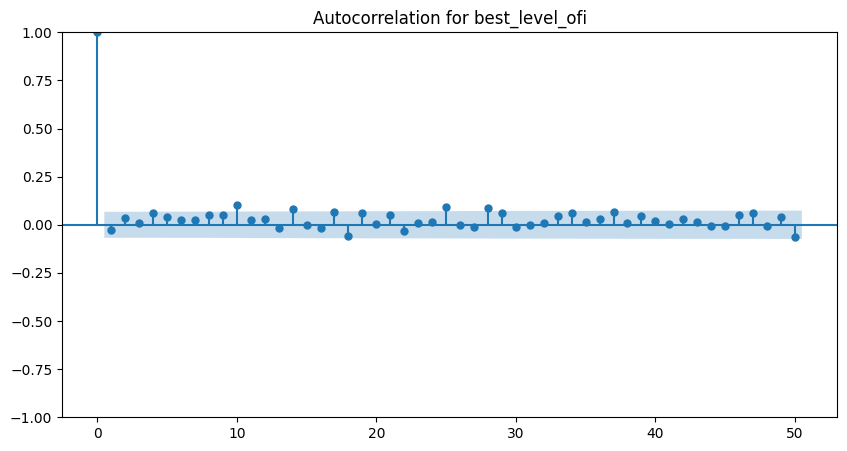

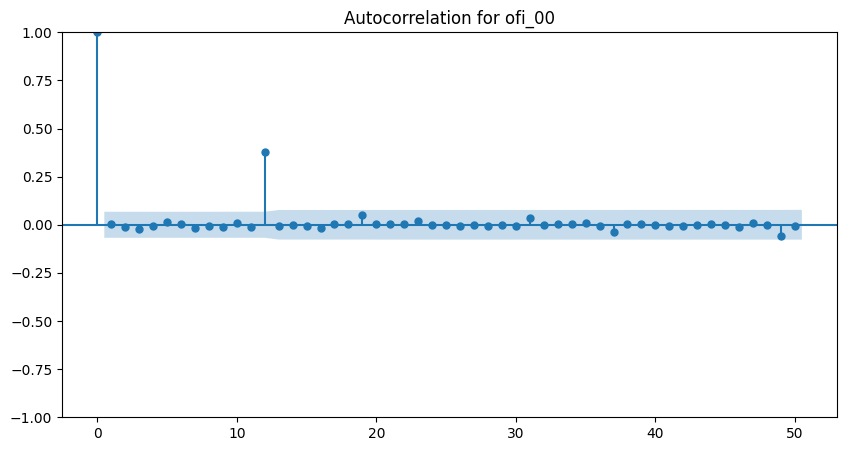

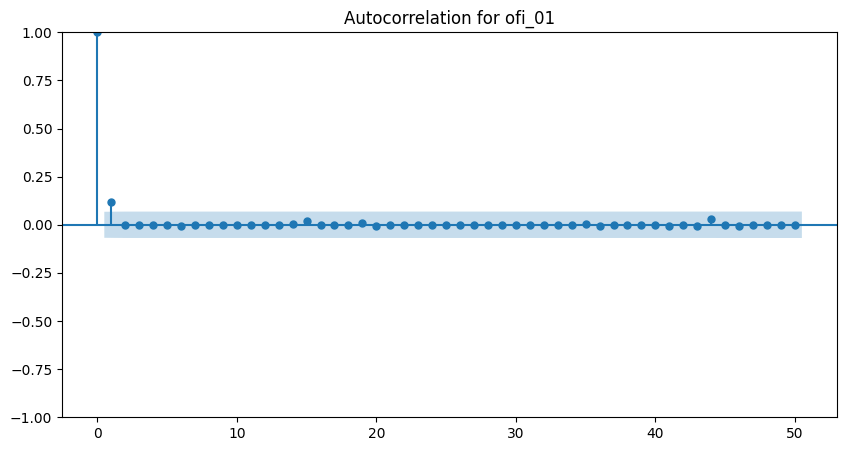

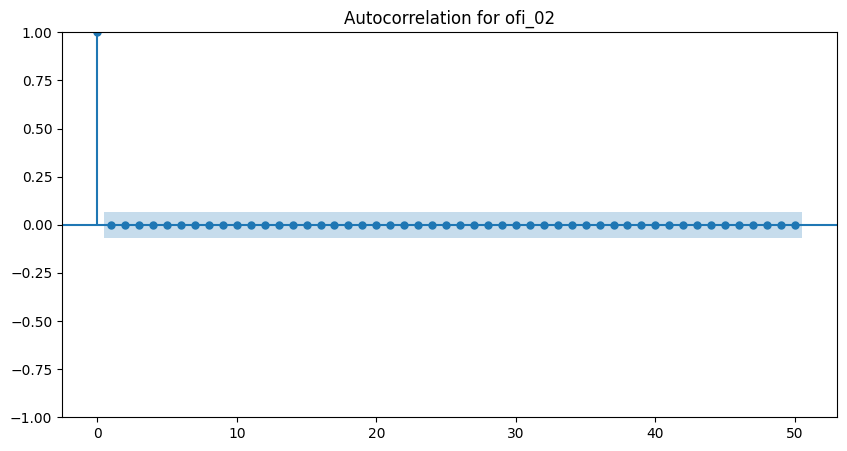

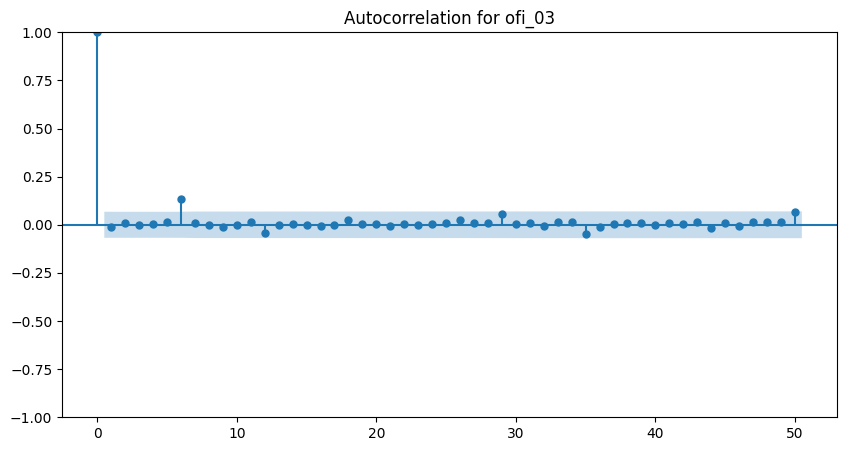

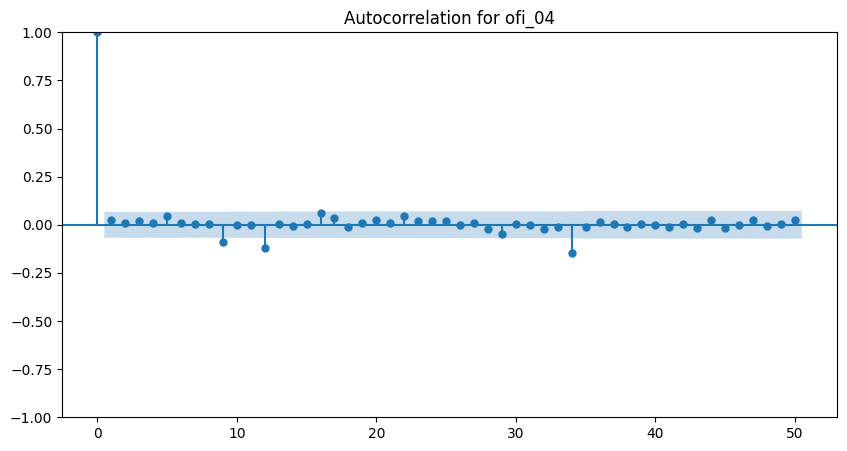

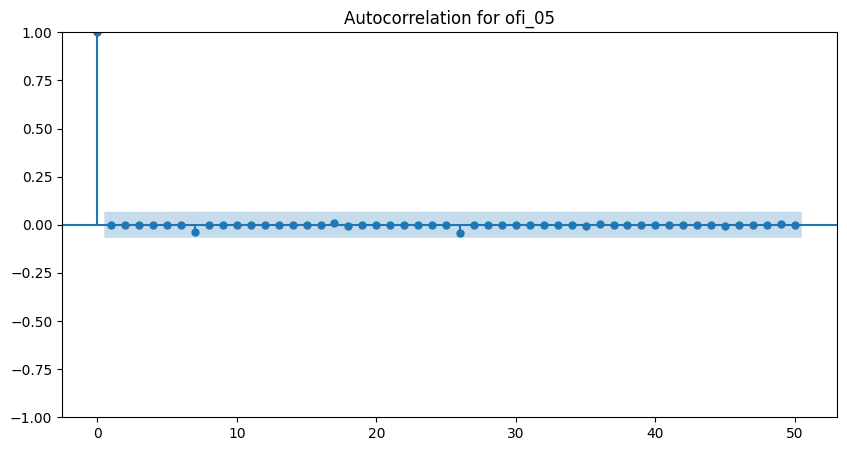

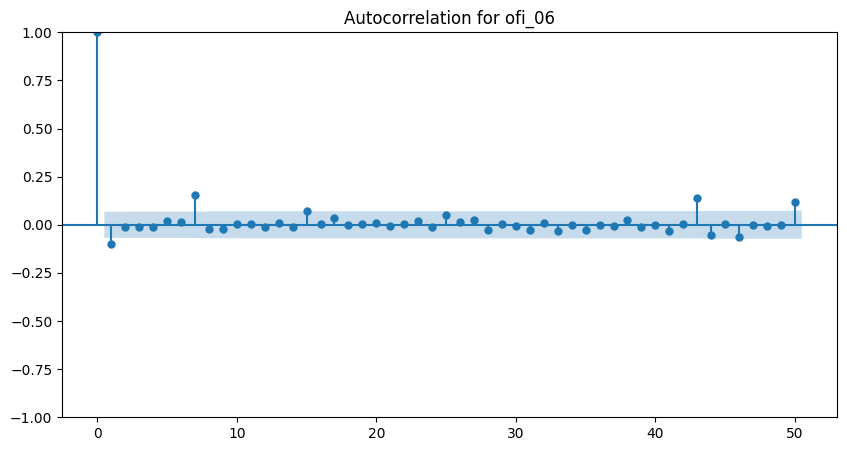

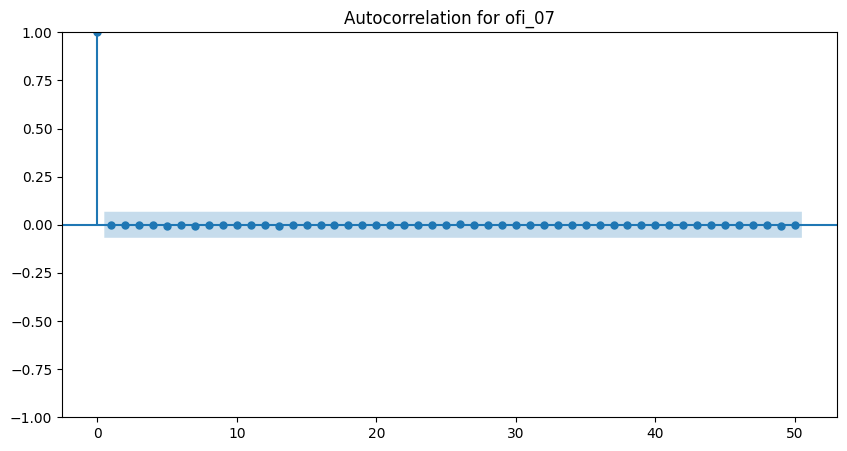

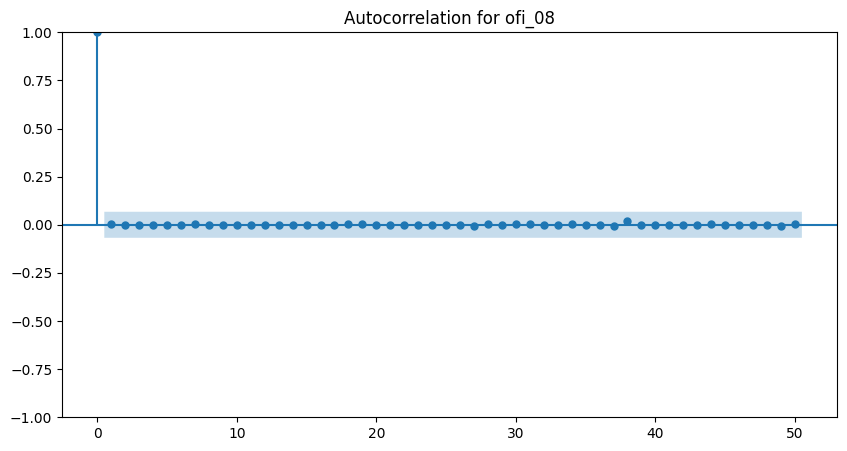

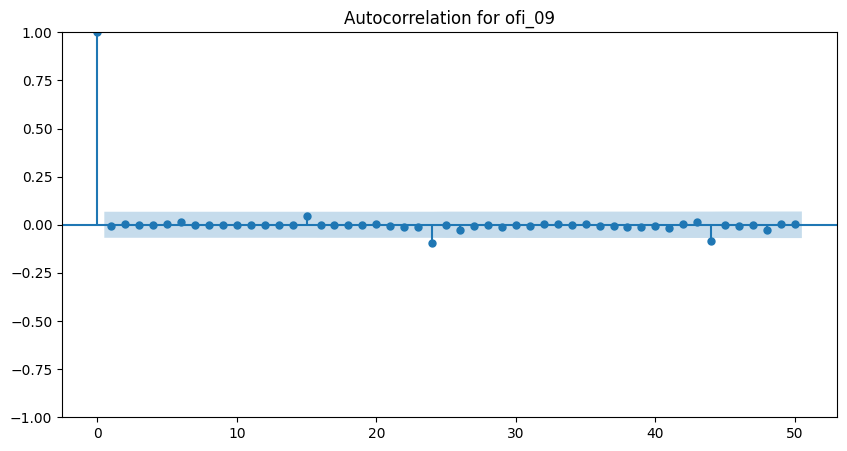

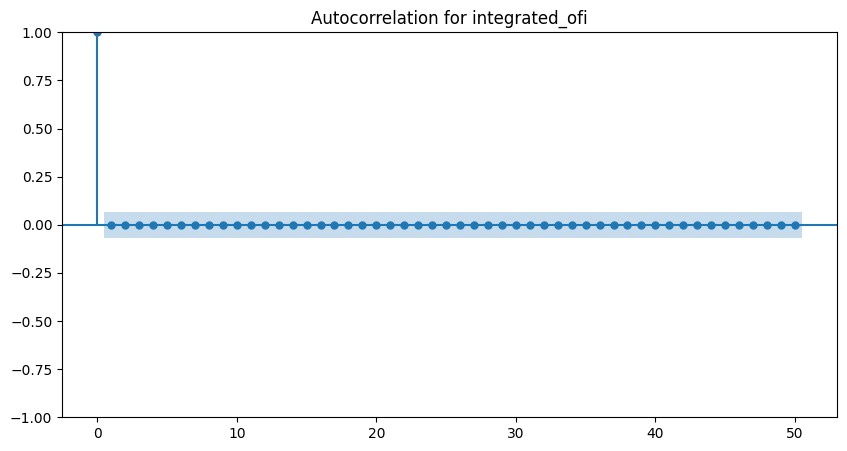

In [112]:
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


def plot_acf_for_df(df, lags=50, alpha=0.05):
    """
    Plots autocorrelation (ACF) for each column in a DataFrame.
    
    Parameters:
        df (pd.DataFrame): Time series data (one column per feature).
        lags (int): Number of lags to compute autocorrelation for.
        alpha (float): Significance level for confidence intervals (default 0.05 → 95% CI).
    """
    for col in df.columns:
        series = df[col].dropna()

        fig, ax = plt.subplots(figsize=(10, 5))
        plot_acf(series, lags=lags, ax=ax, alpha=alpha)
        ax.set_title(f"Autocorrelation for {col}")
        plt.show()

# Example usage:
plot_acf_for_df(ofi_best_level, lags=50)
plot_acf_for_df(multi_level_ofi, lags=50)
plot_acf_for_df(integrated_ofi, lags=50)

Method to Build Lagged Features based on Significant Autocorrelation Lags

In [113]:
def build_lagged_features(ofi_df, col_lags):
    lagged = []
    for col, lags in col_lags.items():
        for lag in lags:
            lagged.append(ofi_df[col].shift(lag).rename(f"{col}_lag{lag}"))
    return pd.concat(lagged, axis=1)

In [114]:
# Lags dictionary

col_lags = {
    "best_level_ofi": [10, 25, 28],
    "ofi_00": [12],
    "ofi_01": [1],
    "ofi_03": [6],
    "ofi_04": [9, 12, 34],
    "ofi_06": [1, 7, 43],
    "ofi_09": [24, 44]
}

# tested simpler lags dictionary

# col_lags = {
#     "best_level_ofi": [10],
#     "ofi_00": [12],
#     "ofi_01": [1],
#     "ofi_03": [6],
#     "ofi_04": [9, 12,
#     "ofi_06": [1, 7],
# }

# building lagged features based on lags dictionary

X = build_lagged_features(ofi_all, col_lags)

# print(X.info())

# lost 245 rows due to lagging :(
merged = (pd.concat([X, price_5s, target_horizons], axis=1).dropna())

# print(merged.info())
print(merged.head())

                           best_level_ofi_lag10  best_level_ofi_lag25  \
ts_event                                                                
2024-10-21 11:58:05+00:00                   0.0                   0.0   
2024-10-21 11:58:10+00:00                 113.0                 746.0   
2024-10-21 11:58:15+00:00                  10.0                -510.0   
2024-10-21 11:58:20+00:00                 200.0                   0.0   
2024-10-21 11:58:30+00:00                   0.0                   0.0   

                           best_level_ofi_lag28  ofi_00_lag12  ofi_01_lag1  \
ts_event                                                                     
2024-10-21 11:58:05+00:00                   0.0    -19.900744          0.0   
2024-10-21 11:58:10+00:00                -205.0      0.000000          0.0   
2024-10-21 11:58:15+00:00                -200.0      0.000000          0.0   
2024-10-21 11:58:20+00:00                   0.0   -218.709677          0.0   
2024-10-21 11:58:30+

Throwing Models at the Data -- trying to gain insights

Random Forest R^2:
  Train: 0.2826068425193623
  Test: -0.04861787243965643


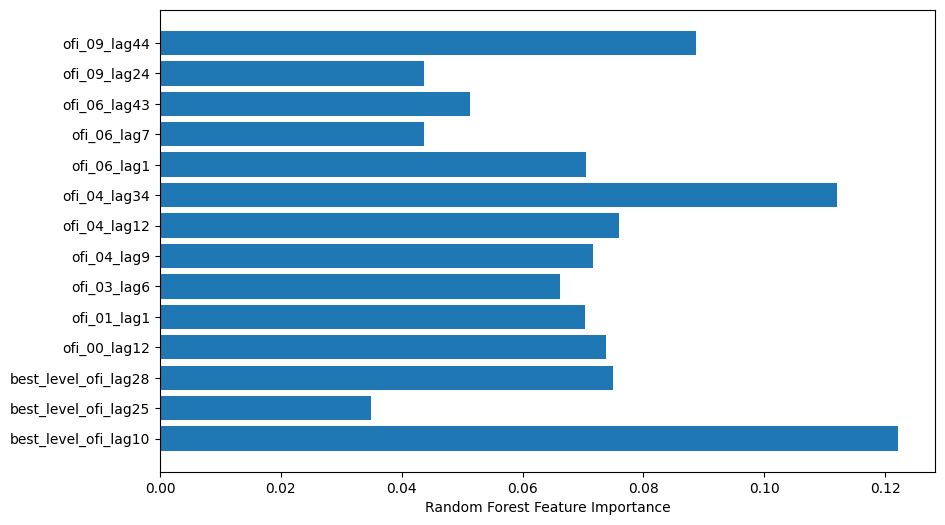

In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# --- 1. Prepare data ---
df = merged  # your merged dataframe
target_col = '5s'

# Select all lagged features only (exclude price and return horizons)
lagged_features = [col for col in df.columns if 'lag' in col]

X = df[lagged_features]
y = df[target_col]

# Time-based train/test split (80% train, 20% test)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 2. Random Forest ---
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest R^2:")
print("  Train:", r2_score(y_train, y_train_pred_rf))
print("  Test:", r2_score(y_test, y_test_pred_rf))

# Feature importance
plt.figure(figsize=(10,6))
plt.barh(lagged_features, rf.feature_importances_)
plt.xlabel("Random Forest Feature Importance")
plt.show()

# I'm going to discard Random Forest for now, as it is not performing well at all.
# I definitely don't think I have enough Level 10 data for now, so I'm going to focus on finding significant features that I can chase down later, when I get the resources.

Ridge Regression using Autocorrelated lags and simple returns (5s horizon)

In [116]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Features = lagged OFI columns
feature_cols = [c for c in merged.columns if "_lag" in c]
X_supervised = merged[feature_cols]
y_supervised = merged["5s"]   # horizon target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_supervised, y_supervised, shuffle=False, test_size=0.2
)

# Fit
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Ridge train R^2:", ridge.score(X_train, y_train))
print("Ridge test R^2:", ridge.score(X_test, y_test))

Ridge train R^2: 0.023541042673182466
Ridge test R^2: 0.00242121124907968


ARIMAX Model with Best-Level and Multi-Level Only

In [117]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

endog = merged["5s"]  # endogenous: returns series
exog = merged[feature_cols]  # exogenous: lagged OFIs

# Simple ARIMAX(p,d,q) — tune later
model = SARIMAX(endog, exog=exog, order=(1,0,1))
res = model.fit(disp=False)

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                     5s   No. Observations:                  595
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 267.930
Date:                Fri, 12 Sep 2025   AIC                           -501.861
Time:                        16:38:38   BIC                           -427.255
Sample:                             0   HQIC                          -472.808
                                - 595                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
best_level_ofi_lag10 -6.404e-06   4.39e-06     -1.460      0.144    -1.5e-05     2.2e-06
best_level_ofi_lag25 -1.216e-06   4.56e-06     -0.267      0.790   -1.02e-05    7.73e-06
best_level_o

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Because a couple Multi-Level Features showed significance, I'm going to try the PCA Integrated Feature but lagged, and see if that helps (should in theory)

In [118]:
# integrated_ofi lags dictionary based on previous ARIMA

integrated_ofi_lags = {
    "integrated_ofi": [12, 34, 44]
}

# standardize
integrated_ofi['integrated_ofi'] = (
    (integrated_ofi['integrated_ofi'] - integrated_ofi['integrated_ofi'].mean())
    / integrated_ofi['integrated_ofi'].std()
)

X = build_lagged_features(integrated_ofi, integrated_ofi_lags).dropna()

# print(X.head())
# I noticed here that I have to fix the scaling of the integrated_ofi lagged features, or my ARIMA run wouldn't do well (Numerical Instability)

merged = (pd.concat([X, price_5s, target_horizons], axis=1).dropna())

# print(merged.info())
# print(merged.head())

from statsmodels.tsa.statespace.sarimax import SARIMAX

endog = merged["5s"]  # endogenous: returns series
exog = merged[[c for c in merged.columns if "_lag" in c]]  # exogenous: lagged OFIs

# Simple ARIMAX(p,d,q) — tune later
model = SARIMAX(endog, exog=exog, order=(1,0,1))
res = model.fit(disp=False)

print(res.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                     5s   No. Observations:                  595
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 294.775
Date:                Fri, 12 Sep 2025   AIC                           -577.551
Time:                        16:38:38   BIC                           -551.219
Sample:                             0   HQIC                          -567.297
                                - 595                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
integrated_ofi_lag12    -0.0010      0.005     -0.219      0.826      -0.010       0.008
integrated_ofi_lag34     0.0004      0.003      0.123      0.902      -0.006       0.007
integrated_o